In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
atc_df = pd.read_csv("../data/processed/master_atc_trolley_eda_adjusted.csv")
benzo_df = pd.read_csv("../data/processed/master_benzo_trolley_eda_adjusted.csv")

In [5]:
atc_df = atc_df.copy()
atc_df["YEAR_MONTH"] = pd.to_datetime(atc_df["YEAR_MONTH"])
atc_df = atc_df.sort_values("YEAR_MONTH").reset_index(drop=True)

benzo_df = benzo_df.copy()
benzo_df["YEAR_MONTH"] = pd.to_datetime(benzo_df["YEAR_MONTH"])
benzo_df = benzo_df.sort_values("YEAR_MONTH").reset_index(drop=True)

In [6]:
pressure_vars = [
    "Monthly_Total_Pressure",
    "Monthly_Trolley_Total",
    "Monthly_Ward_Total"
]

In [7]:
j01_lag_results = []
j01_lag_test = atc_df[["YEAR_MONTH", "J01", "Monthly_Total_Pressure"]].copy()

for lag in range(0, 13):
    lag_col = f"J01_lag_{lag}"
    j01_lag_test[lag_col] = j01_lag_test["J01"].shift(lag)
    
    temp = j01_lag_test[[lag_col, "Monthly_Total_Pressure"]].dropna()
    
    corr = temp[lag_col].corr(temp["Monthly_Total_Pressure"])
    
    j01_lag_results.append({
        "variable": "J01",
        "pressure_variable": "Monthly_Total_Pressure",
        "lag_months": lag,
        "n": len(temp),
        "pearson_corr": corr
    })

j01_lag_results = pd.DataFrame(j01_lag_results)

j01_lag_results

,variable,pressure_variable,lag_months,n,pearson_corr
0,J01,Monthly_Total_Pressure,0,120,0.647825
1,J01,Monthly_Total_Pressure,1,119,0.572169
2,J01,Monthly_Total_Pressure,2,118,0.436455
3,J01,Monthly_Total_Pressure,3,117,0.278394
4,J01,Monthly_Total_Pressure,4,116,0.144385
5,J01,Monthly_Total_Pressure,5,115,0.045696
6,J01,Monthly_Total_Pressure,6,114,0.006096
7,J01,Monthly_Total_Pressure,7,113,-0.006915
8,J01,Monthly_Total_Pressure,8,112,0.108200
9,J01,Monthly_Total_Pressure,9,111,0.169973


In [8]:
def lag_correlation_table(df, x_vars, y_vars, max_lag=12):
    results = []
    
    for x in x_vars:
        for y in y_vars:
            for lag in range(0, max_lag + 1):
                lag_col = f"{x}_lag_{lag}"
                
                temp = df[[x, y]].copy()
                temp[lag_col] = temp[x].shift(lag)
                temp = temp[[lag_col, y]].dropna()
                
                corr = temp[lag_col].corr(temp[y])
                
                results.append({
                    "variable": x,
                    "pressure_variable": y,
                    "lag_months": lag,
                    "n": len(temp),
                    "pearson_corr": corr
                })
    
    return pd.DataFrame(results)

In [9]:
non_prescribing_cols = [
    "YEAR_MONTH",
    "Monthly_Trolley_Total",
    "Monthly_Ward_Total",
    "Monthly_Total_Pressure"
]

all_atc_vars = [
    col for col in atc_df.columns
    if col not in non_prescribing_cols
]

all_atc_vars

['A01',
 'A02',
 'A03',
 'A04',
 'A05',
 'A06',
 'A07',
 'A09',
 'A10',
 'A11',
 'A12',
 'A14',
 'B01',
 'B02',
 'B03',
 'B05',
 'C01',
 'C02',
 'C03',
 'C04',
 'C05',
 'C07',
 'C08',
 'C09',
 'C10',
 'D01',
 'D02',
 'D03',
 'D05',
 'D06',
 'D07',
 'D10',
 'D11',
 'G01',
 'G02',
 'G03',
 'G04',
 'H01',
 'H02',
 'H03',
 'H04',
 'J01',
 'J02',
 'J04',
 'J05',
 'L01',
 'L02',
 'L04',
 'M01',
 'M02',
 'M03',
 'M04',
 'M05',
 'M09',
 'N01',
 'N02',
 'N03',
 'N04',
 'N05',
 'N06',
 'N07',
 'P01',
 'P02',
 'P03',
 'R01',
 'R03',
 'R05',
 'R06',
 'S01',
 'S02',
 'S03',
 'V01',
 'V03',
 'V04',
 'V06',
 'V07 1',
 'V07 2',
 'V07 3',
 'V07 4',
 'V07 5']

In [10]:
atc_lag_corr_all = lag_correlation_table(
    df=atc_df,
    x_vars=all_atc_vars,
    y_vars=pressure_vars,
    max_lag=12
)

atc_lag_corr_all.head(20)

,variable,pressure_variable,lag_months,n,pearson_corr
0,A01,Monthly_Total_Pressure,0,120,0.426695
1,A01,Monthly_Total_Pressure,1,119,0.407695
2,A01,Monthly_Total_Pressure,2,118,0.377566
3,A01,Monthly_Total_Pressure,3,117,0.362757
4,A01,Monthly_Total_Pressure,4,116,0.318152
5,A01,Monthly_Total_Pressure,5,115,0.297374
6,A01,Monthly_Total_Pressure,6,114,0.259652
7,A01,Monthly_Total_Pressure,7,113,0.260003
8,A01,Monthly_Total_Pressure,8,112,0.283735
9,A01,Monthly_Total_Pressure,9,111,0.285129


In [11]:
atc_total_lag_corr = atc_lag_corr_all[
    atc_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total"
].copy()


atc_best_lags_total = atc_total_lag_corr.loc[
    atc_total_lag_corr.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)

atc_best_lags_total.head(20)

,variable,pressure_variable,lag_months,n,pearson_corr
2743,S03,Monthly_Trolley_Total,0,120,0.696098
1612,J01,Monthly_Trolley_Total,0,120,0.617585
1651,J02,Monthly_Trolley_Total,0,120,0.550303
2587,R05,Monthly_Trolley_Total,0,120,0.546242
1384,G03,Monthly_Trolley_Total,6,114,0.458792
799,C05,Monthly_Trolley_Total,6,114,0.425969
2398,P01,Monthly_Trolley_Total,6,114,0.410268
2470,P03,Monthly_Trolley_Total,0,120,0.393331
1768,L01,Monthly_Trolley_Total,0,120,0.390787
2790,V01,Monthly_Trolley_Total,8,112,0.390763


In [12]:
atc_total_lag_corr = atc_lag_corr_all[
    atc_lag_corr_all["pressure_variable"] == "Monthly_Total_Pressure"
].copy()

atc_best_lags_total = atc_total_lag_corr.loc[
    atc_total_lag_corr.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)

atc_best_lags_total.head(20)

,variable,pressure_variable,lag_months,n,pearson_corr
2730,S03,Monthly_Total_Pressure,0,120,0.669752
1599,J01,Monthly_Total_Pressure,0,120,0.647825
1638,J02,Monthly_Total_Pressure,0,120,0.633456
2574,R05,Monthly_Total_Pressure,0,120,0.593313
1371,G03,Monthly_Total_Pressure,6,114,0.483464
2894,V06,Monthly_Total_Pressure,8,112,0.480729
2418,P02,Monthly_Total_Pressure,0,120,0.473190
2457,P03,Monthly_Total_Pressure,0,120,0.464861
786,C05,Monthly_Total_Pressure,6,114,0.461112
2385,P01,Monthly_Total_Pressure,6,114,0.446217


In [13]:
candidate_atc_vars = ["J01", "R03", "R06", "S03", "J02", "R05"]

atc_candidate_lags = atc_lag_corr_all[
    (atc_lag_corr_all["variable"].isin(candidate_atc_vars)) &
    (atc_lag_corr_all["pressure_variable"] == "Monthly_Total_Pressure")
].copy()

atc_candidate_lags.sort_values(
    by=["variable", "lag_months"]
)

,variable,pressure_variable,lag_months,n,pearson_corr
1599,J01,Monthly_Total_Pressure,0,120,0.647825
1600,J01,Monthly_Total_Pressure,1,119,0.572169
1601,J01,Monthly_Total_Pressure,2,118,0.436455
1602,J01,Monthly_Total_Pressure,3,117,0.278394
1603,J01,Monthly_Total_Pressure,4,116,0.144385
...,...,...,...,...,...
2738,S03,Monthly_Total_Pressure,8,112,0.268966
2739,S03,Monthly_Total_Pressure,9,111,0.292586
2740,S03,Monthly_Total_Pressure,10,110,0.355267
2741,S03,Monthly_Total_Pressure,11,109,0.355623


In [14]:
atc_candidate_best_lags = atc_candidate_lags.loc[
    atc_candidate_lags.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)

atc_candidate_best_lags

,variable,pressure_variable,lag_months,n,pearson_corr
2730,S03,Monthly_Total_Pressure,0,120,0.669752
1599,J01,Monthly_Total_Pressure,0,120,0.647825
1638,J02,Monthly_Total_Pressure,0,120,0.633456
2574,R05,Monthly_Total_Pressure,0,120,0.593313
2618,R06,Monthly_Total_Pressure,5,115,0.355444
2535,R03,Monthly_Total_Pressure,0,120,0.260129


In [15]:
atc_candidate_best_by_pressure = atc_lag_corr_all[
    atc_lag_corr_all["variable"].isin(candidate_atc_vars)
].copy()

atc_candidate_best_by_pressure = atc_candidate_best_by_pressure.loc[
    atc_candidate_best_by_pressure.groupby(["variable", "pressure_variable"])["pearson_corr"].idxmax()
].sort_values(["pressure_variable", "pearson_corr"], ascending=[True, False])

atc_candidate_best_by_pressure

,variable,pressure_variable,lag_months,n,pearson_corr
2730,S03,Monthly_Total_Pressure,0,120,0.669752
1599,J01,Monthly_Total_Pressure,0,120,0.647825
1638,J02,Monthly_Total_Pressure,0,120,0.633456
2574,R05,Monthly_Total_Pressure,0,120,0.593313
2618,R06,Monthly_Total_Pressure,5,115,0.355444
2535,R03,Monthly_Total_Pressure,0,120,0.260129
2743,S03,Monthly_Trolley_Total,0,120,0.696098
1612,J01,Monthly_Trolley_Total,0,120,0.617585
1651,J02,Monthly_Trolley_Total,0,120,0.550303
2587,R05,Monthly_Trolley_Total,0,120,0.546242


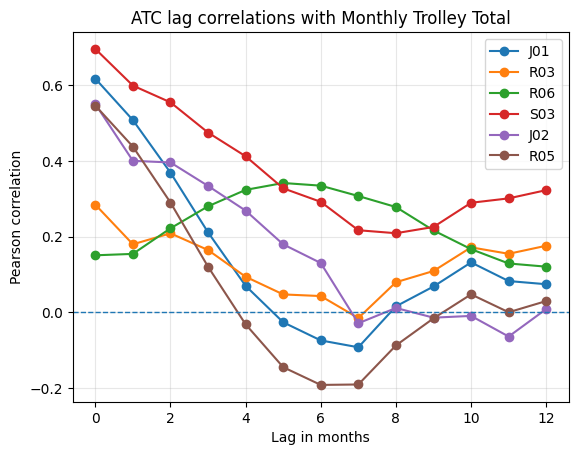

In [16]:
for var in candidate_atc_vars:
    temp = atc_lag_corr_all[
        (atc_lag_corr_all["variable"] == var) &
        (atc_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total")
    ]
    
    plt.plot(
        temp["lag_months"],
        temp["pearson_corr"],
        marker="o",
        label=var
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag in months")
plt.ylabel("Pearson correlation")
plt.title("ATC lag correlations with Monthly Trolley Total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
atc_lag_corr_all.to_csv("../outputs/atc_lag_correlations_all_0_to_12.csv", index=False)
atc_candidate_best_by_pressure.to_csv("../outputs/atc_candidate_best_lags_by_pressure.csv", index=False)

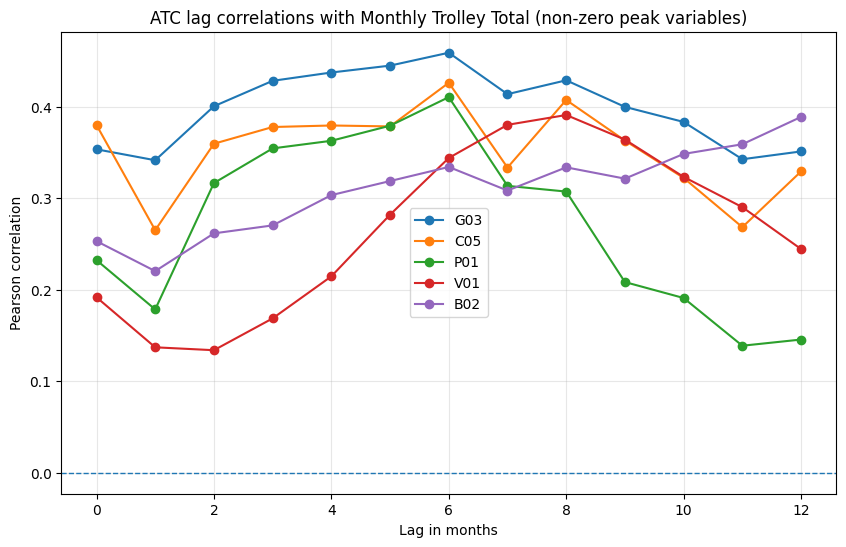

In [18]:
other_lag_peak_vars = ["G03", "C05", "P01", "V01", "B02"]

plt.figure(figsize=(10, 6))

for var in other_lag_peak_vars:
    temp = atc_lag_corr_all[
        (atc_lag_corr_all["variable"] == var) &
        (atc_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total")
    ]
    
    plt.plot(
        temp["lag_months"],
        temp["pearson_corr"],
        marker="o",
        label=var
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag in months")
plt.ylabel("Pearson correlation")
plt.title("ATC lag correlations with Monthly Trolley Total (non-zero peak variables)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
non_prescribing_cols_benzo = [
    "YEAR_MONTH",
    "Monthly_Trolley_Total",
    "Monthly_Ward_Total",
    "Monthly_Total_Pressure"
]

all_benzo_vars = [
    col for col in benzo_df.columns
    if col not in non_prescribing_cols_benzo
]

all_benzo_vars

['BENZO_FREQ_N03AE01',
 'BENZO_FREQ_N05BA01',
 'BENZO_FREQ_N05BA02',
 'BENZO_FREQ_N05BA05',
 'BENZO_FREQ_N05BA06',
 'BENZO_FREQ_N05BA08',
 'BENZO_FREQ_N05BA09',
 'BENZO_FREQ_N05BA11',
 'BENZO_FREQ_N05BA12',
 'BENZO_FREQ_N05CD01',
 'BENZO_FREQ_N05CD02',
 'BENZO_FREQ_N05CD05',
 'BENZO_FREQ_N05CD07',
 'BENZO_FREQ_N05CD08',
 'BENZO_FREQ_N05CF01',
 'BENZO_FREQ_N05CF02',
 'BENZO_PATIENTS_N03AE01',
 'BENZO_PATIENTS_N05BA01',
 'BENZO_PATIENTS_N05BA02',
 'BENZO_PATIENTS_N05BA05',
 'BENZO_PATIENTS_N05BA06',
 'BENZO_PATIENTS_N05BA08',
 'BENZO_PATIENTS_N05BA09',
 'BENZO_PATIENTS_N05BA11',
 'BENZO_PATIENTS_N05BA12',
 'BENZO_PATIENTS_N05CD01',
 'BENZO_PATIENTS_N05CD02',
 'BENZO_PATIENTS_N05CD05',
 'BENZO_PATIENTS_N05CD07',
 'BENZO_PATIENTS_N05CD08',
 'BENZO_PATIENTS_N05CF01',
 'BENZO_PATIENTS_N05CF02',
 'Total_Benzo_Frequency',
 'Total_Benzo_Patients']

In [20]:
benzo_lag_corr_all = lag_correlation_table(
    df=benzo_df,
    x_vars=all_benzo_vars,
    y_vars=pressure_vars,
    max_lag=12
)

benzo_lag_corr_all.head(10)

,variable,pressure_variable,lag_months,n,pearson_corr
0,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,0,96,-0.456553
1,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,1,95,-0.456565
2,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,2,94,-0.427190
3,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,3,93,-0.373590
4,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,4,92,-0.345841
5,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,5,91,-0.328777
6,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,6,90,-0.307675
7,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,7,89,-0.327151
8,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,8,88,-0.318154
9,BENZO_FREQ_N03AE01,Monthly_Total_Pressure,9,87,-0.288181


In [21]:
benzo_total_lag_corr = benzo_lag_corr_all[
    benzo_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total"
].copy()

benzo_best_lags_total = benzo_total_lag_corr.loc[
    benzo_total_lag_corr.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)

benzo_best_lags_total.head(20)

,variable,pressure_variable,lag_months,n,pearson_corr
871,BENZO_PATIENTS_N05BA09,Monthly_Trolley_Total,0,96,0.448240
247,BENZO_FREQ_N05BA09,Monthly_Trolley_Total,0,96,0.413003
52,BENZO_FREQ_N05BA01,Monthly_Trolley_Total,0,96,0.351649
676,BENZO_PATIENTS_N05BA01,Monthly_Trolley_Total,0,96,0.335380
130,BENZO_FREQ_N05BA05,Monthly_Trolley_Total,0,96,0.172839
754,BENZO_PATIENTS_N05BA05,Monthly_Trolley_Total,0,96,0.152387
532,BENZO_FREQ_N05CD08,Monthly_Trolley_Total,12,84,0.114916
1234,BENZO_PATIENTS_N05CF02,Monthly_Trolley_Total,12,84,0.045651
559,BENZO_FREQ_N05CF01,Monthly_Trolley_Total,0,96,0.032255
181,BENZO_FREQ_N05BA06,Monthly_Trolley_Total,12,84,0.027854


In [22]:
benzo_worst_lags_total = benzo_total_lag_corr.loc[
    benzo_total_lag_corr.groupby("variable")["pearson_corr"].idxmin()
].sort_values("pearson_corr", ascending=True)

benzo_worst_lags_total.head(20)

,variable,pressure_variable,lag_months,n,pearson_corr
408,BENZO_FREQ_N05CD02,Monthly_Trolley_Total,5,91,-0.559745
1032,BENZO_PATIENTS_N05CD02,Monthly_Trolley_Total,5,91,-0.557774
637,BENZO_PATIENTS_N03AE01,Monthly_Trolley_Total,0,96,-0.470007
13,BENZO_FREQ_N03AE01,Monthly_Trolley_Total,0,96,-0.452625
102,BENZO_FREQ_N05BA02,Monthly_Trolley_Total,11,85,-0.392324
726,BENZO_PATIENTS_N05BA02,Monthly_Trolley_Total,11,85,-0.391483
287,BENZO_FREQ_N05BA11,Monthly_Trolley_Total,1,95,-0.385072
911,BENZO_PATIENTS_N05BA11,Monthly_Trolley_Total,1,95,-0.383674
1301,Total_Benzo_Patients,Monthly_Trolley_Total,1,95,-0.377535
764,BENZO_PATIENTS_N05BA05,Monthly_Trolley_Total,10,86,-0.376282


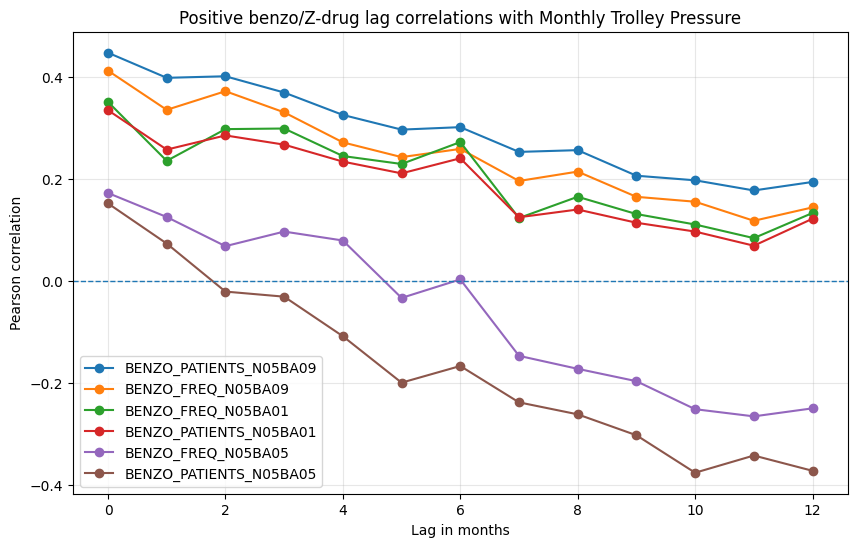

In [23]:
positive_benzo_vars = [
    "BENZO_PATIENTS_N05BA09",
    "BENZO_FREQ_N05BA09",
    "BENZO_FREQ_N05BA01",
    "BENZO_PATIENTS_N05BA01",
    "BENZO_FREQ_N05BA05",
    "BENZO_PATIENTS_N05BA05"
]

plt.figure(figsize=(10, 6))

for var in positive_benzo_vars:
    temp = benzo_lag_corr_all[
        (benzo_lag_corr_all["variable"] == var) &
        (benzo_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total")
    ]
    
    plt.plot(
        temp["lag_months"],
        temp["pearson_corr"],
        marker="o",
        label=var
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag in months")
plt.ylabel("Pearson correlation")
plt.title("Positive benzo/Z-drug lag correlations with Monthly Trolley Pressure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

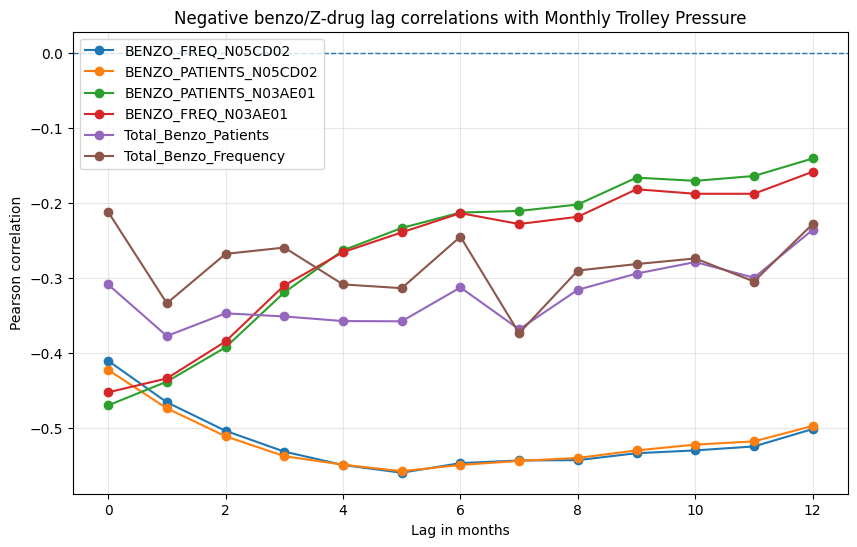

In [24]:
negative_benzo_vars = [
    "BENZO_FREQ_N05CD02",
    "BENZO_PATIENTS_N05CD02",
    "BENZO_PATIENTS_N03AE01",
    "BENZO_FREQ_N03AE01",
    "Total_Benzo_Patients",
    "Total_Benzo_Frequency"
]

plt.figure(figsize=(10, 6))

for var in negative_benzo_vars:
    temp = benzo_lag_corr_all[
        (benzo_lag_corr_all["variable"] == var) &
        (benzo_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total")
    ]
    
    plt.plot(
        temp["lag_months"],
        temp["pearson_corr"],
        marker="o",
        label=var
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag in months")
plt.ylabel("Pearson correlation")
plt.title("Negative benzo/Z-drug lag correlations with Monthly Trolley Pressure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
benzo_lag_corr_all.to_csv("../outputs/benzo_lag_correlations_all_0_to_12.csv", index=False)
benzo_best_lags_total.to_csv("../outputs/benzo_best_lags_total_pressure.csv", index=False)
benzo_worst_lags_total.to_csv("../outputs/benzo_strongest_negative_lags_total_pressure.csv", index=False)

In [26]:
benzo_ed_lag_corr = benzo_lag_corr_all[
    benzo_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total"
].copy()

benzo_best_lags_ed = benzo_ed_lag_corr.loc[
    benzo_ed_lag_corr.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)

benzo_worst_lags_ed = benzo_ed_lag_corr.loc[
    benzo_ed_lag_corr.groupby("variable")["pearson_corr"].idxmin()
].sort_values("pearson_corr", ascending=True)

benzo_best_lags_ed.to_csv("../outputs/benzo_best_lags_ed_pressure.csv", index=False)
benzo_worst_lags_ed.to_csv("../outputs/benzo_strongest_negative_lags_ed_pressure.csv", index=False)

In [27]:

atc_ed_lag_corr = atc_lag_corr_all[
    atc_lag_corr_all["pressure_variable"] == "Monthly_Trolley_Total"
].copy()

atc_best_lags_ed = atc_ed_lag_corr.loc[
    atc_ed_lag_corr.groupby("variable")["pearson_corr"].idxmax()
].sort_values("pearson_corr", ascending=False)


atc_best_lags_ed.to_csv("../outputs/atc_best_lags_ed_pressure.csv", index=False)
